<a href="https://colab.research.google.com/github/hibadash/AI-Based-Driver-Drowsiness-Detection-for-Automotive-Applications/blob/main/MRL_Drowsiness_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Download Dataset : MRL Eye dataset**

In [2]:
!pip install kagglehub


**Verifying content of each folder**

In [19]:
import os

raw_data_dir = "/content/mrl-eye-dataset/data"

for subset in ["train", "val", "test"]:
    subset_path = os.path.join(raw_data_dir, subset)
    print(f"Contents of {subset_path}: {os.listdir(subset_path)[:10]}")


Contents of /content/mrl-eye-dataset/data/train: ['sleepy', 'awake']
Contents of /content/mrl-eye-dataset/data/val: ['sleepy', 'awake']
Contents of /content/mrl-eye-dataset/data/test: ['sleepy', 'awake']


**Organize and Sort the Dataset**

In [20]:
import os
import shutil

raw_data_dir = "/content/mrl-eye-dataset/data"
output_dir = "/content/dataset"
open_dir = os.path.join(output_dir, "open")
closed_dir = os.path.join(output_dir, "closed")

os.makedirs(open_dir, exist_ok=True)
os.makedirs(closed_dir, exist_ok=True)

count_open = 0
count_closed = 0
MAX_IMAGES_PER_CLASS = 500

# Loop through subsets and class folders
for subset in ["train", "val", "test"]:
    for class_folder, target_dir in [("awake", open_dir), ("sleepy", closed_dir)]:
        subset_path = os.path.join(raw_data_dir, subset, class_folder)
        for file in os.listdir(subset_path):
            if not file.lower().endswith((".png", ".jpg")):
                continue
            src_path = os.path.join(subset_path, file)
            if target_dir == open_dir and count_open < MAX_IMAGES_PER_CLASS:
                shutil.copy(src_path, open_dir)
                count_open += 1
            elif target_dir == closed_dir and count_closed < MAX_IMAGES_PER_CLASS:
                shutil.copy(src_path, closed_dir)
                count_closed += 1

            if count_open >= MAX_IMAGES_PER_CLASS and count_closed >= MAX_IMAGES_PER_CLASS:
                break
        if count_open >= MAX_IMAGES_PER_CLASS and count_closed >= MAX_IMAGES_PER_CLASS:
            break
    if count_open >= MAX_IMAGES_PER_CLASS and count_closed >= MAX_IMAGES_PER_CLASS:
        break

print("Open images:", count_open)
print("Closed images:", count_closed)


Open images: 500
Closed images: 500


**Preprocessing + CNN Training**

In [23]:
import os
print("Open images:", len(os.listdir("/content/dataset/open")))
print("Closed images:", len(os.listdir("/content/dataset/closed")))


Open images: 500
Closed images: 500


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 635ms/step - accuracy: 0.9235 - loss: 0.1966 - val_accuracy: 0.8850 - val_loss: 0.2967
Epoch 23/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 639ms/step - accuracy: 0.9056 - loss: 0.2096 - val_accuracy: 0.8600 - val_loss: 0.2975
Epoch 24/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 616ms/step - accuracy: 0.9245 - loss: 0.2041 - val_accuracy: 0.8700 - val_loss: 0.3035
Epoch 25/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9159 - loss: 0.1977

25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 676ms/step - accuracy: 0.9161 - loss: 0.1976 - val_accuracy: 0.8900 - val_loss: 0.2909
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.5673 - loss: 1.0091

25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 889ms/step - accuracy: 0.5698 - loss: 1.0005 - val_accuracy: 0.8800 - val_loss: 0.2866
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.7441 - loss: 0.5291

25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 847ms/step - accuracy: 0.7462 - loss: 0.5253 - val_accuracy: 0.8950 - val_loss: 0.2713
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 775ms/step - accuracy: 0.8587 - loss: 0.3163 - val_accuracy: 0.8850 - val_loss: 0.3393
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 824ms/step - accuracy: 0.8777 - loss: 0.2738 - val_accuracy: 0.8350 - val_loss: 0.3842
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 782ms/step - accuracy: 0.8757 - loss: 0.2811 - val_accuracy: 0.8100 - val_loss: 0.4256
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 832ms/step - accuracy: 0.9223 - loss: 0.2094 - val_accuracy: 0.7950 - val_loss: 0.4457
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 781ms/step - accuracy: 0.9033 - loss: 0.2429 - val_accuracy: 0.7250 - val_loss: 0.4808


Final model saved to: /content/drowsiness_mobilenet_final.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 787ms/step
Confusion Matrix:
 [[91  9]
 [15 85]]
Classification Report:
               precision    recall  f1-score   support

        Open       0.86      0.91      0.88       100
      Closed       0.90      0.85      0.88       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



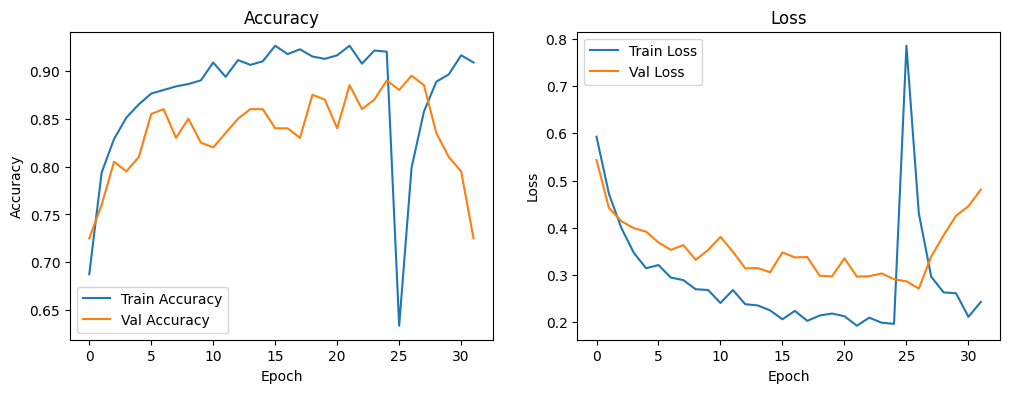

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Paths and Parameters

dataset_dir = "/content/dataset"
IMG_WIDTH, IMG_HEIGHT = 128, 128
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.0001  # small Learning Rate for fine-tuning

# Data processing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)
#Compute class weights

# -----------------------------
y_train = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)


#  Build the Model with MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))
base_model.trainable = False  # freeze base for costumized model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/best_drowsiness_mobilenet.h5", monitor='val_loss', save_best_only=True)


# Train the Model  | Top layer

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights_dict,
    verbose=1
)

# Fine-tune last layers

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE/10),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights_dict,
    verbose=1
)

# Saving final model

model_path = "/content/drowsiness_mobilenet_final.h5"
model.save(model_path)
print("Final model saved to:", model_path)

# Model evaluation
val_generator.reset()
y_true = val_generator.classes
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=['Open','Closed'])

print("Confusion Matrix:\n", cm)
print("Classification Report:\n", report)

# Plot training curves

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_finetune.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_finetune.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


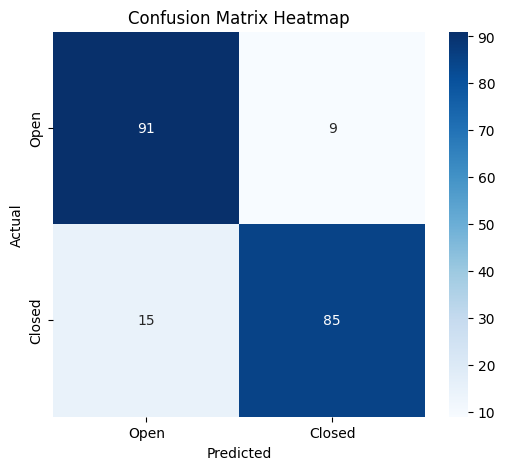

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)
classes = ['Open', 'Closed']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()
